## Task 0

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [2]:
DATA_DIR = Path(".")

COMMODITY_FILE = DATA_DIR / "Commodities Data thru 15May25.xlsx"
AUXILIARY_FILE = DATA_DIR / "DataTables Updated thru 15May25.xlsx"

commodity_xls = pd.ExcelFile(COMMODITY_FILE)
auxiliary_xls = pd.ExcelFile(AUXILIARY_FILE)

print("Commodity file sheets:")
print(commodity_xls.sheet_names)

print("\nAuxiliary file sheets:")
print(auxiliary_xls.sheet_names)

Commodity file sheets:
['Return Indices', 'Assets']

Auxiliary file sheets:
['VARIABLES', 'FX SPOT', 'ATM VOLS', '3M 25D RR', '3M DEPOSIT RATES', '10Y YIELD', 'EQUITY INDICES', 'COMDTY', 'CREDIT SPREADS', 'JPM EASI', 'IMM POSITIONING', '1M EUR FWD', 'BBG Formula']


In [3]:
raw_indices = pd.read_excel(
    COMMODITY_FILE,
    sheet_name="Return Indices",
    na_values=["#N/A N/A", "#N/A", "N/A", "NA", ""]
)

In [4]:
return_indices = raw_indices.copy()

date_col = return_indices.columns[0]
return_indices = return_indices.rename(columns={date_col: "Date"})
return_indices["Date"] = pd.to_datetime(return_indices["Date"], errors="coerce")
return_indices = return_indices.dropna(subset=["Date"])
return_indices = return_indices.set_index("Date")
return_indices = return_indices.sort_index()
return_indices = return_indices.apply(pd.to_numeric, errors="coerce")

return_indices.head()

,LIVE CATTLE FUTR Aug25,LEAN HOGS FUTURE Jul25,COFFEE 'C' FUTURE Jul25,CORN FUTURE Jul25,COTTON NO.2 FUTR Jul25,SOYBEAN FUTURE Jul25,SUGAR #11 (WORLD) Jul25,WHEAT FUTURE(CBT) Jul25,BRENT CRUDE FUTR Jul25,COPPER FUTURE Jul25,GASOLINE RBOB FUT Jun25,GOLD 100 OZ FUTR Jun25,NATURAL GAS FUTR Jun25,SILVER FUTURE Jul25,PLATINUM FUTURE Jul25,WTI CRUDE FUTURE Jun25,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA FUTURE Jul25,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
1969-01-01,100.000000,NaN,NaN,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN
1969-01-02,99.195767,NaN,NaN,99.579019,100.760109,99.863919,100.977591,99.816382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.305113,NaN
1969-01-03,98.746032,NaN,NaN,100.004551,101.269383,99.611198,101.298991,99.631766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.430847,NaN
1969-01-06,98.746032,NaN,NaN,100.216179,101.847066,99.416796,100.325864,98.804487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.209556,NaN
1969-01-07,99.195767,NaN,NaN,100.216179,100.874126,99.183515,99.352736,97.882405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.826488,NaN


In [6]:
# check time range and number of assets
print("Start date:", return_indices.index.min())
print("End date:", return_indices.index.max())
print("Number of assets:", return_indices.shape[1])                                                                                                     

Start date: 1969-01-01 00:00:00
End date: 2025-05-15 00:00:00
Number of assets: 23


In [7]:
# assets info
assets = pd.read_excel(
    COMMODITY_FILE,
    sheet_name="Assets"
)

assets.head()

,Commodity,Sector
0,LIVE CATTLE,Agri & livestock
1,LEAN HOGS,Agri & livestock
2,COFFEE 'C',Agri & livestock
3,CORN,Agri & livestock
4,COTTON NO.2,Agri & livestock


In [8]:
# clean up asset info
assets = assets.copy()

assets["Commodity"] = assets["Commodity"].astype(str).str.strip()
assets["Sector"] = assets["Sector"].astype(str).str.strip()

assets = assets.dropna(subset=["Commodity", "Sector"])

assets

,Commodity,Sector
0,LIVE CATTLE,Agri & livestock
1,LEAN HOGS,Agri & livestock
2,COFFEE 'C',Agri & livestock
3,CORN,Agri & livestock
4,COTTON NO.2,Agri & livestock
5,SOYBEAN,Agri & livestock
6,SUGAR #11,Agri & livestock
7,WHEAT FUTURE,Agri & livestock
8,BRENT CRUDE,Energy
9,COPPER FUTURE,Metals


In [9]:
assets["Sector"].value_counts()

Sector
Agri & livestock    9
Metals              9
Energy              5
Name: count, dtype: int64

In [10]:
# the assets name in the return indices sheet are not indentical to the assets name in the assets sheet, so we need to match them up.
def normalise_name(x):
    return " ".join(str(x).upper().split())


old_cols = return_indices.columns.tolist()
asset_names = assets["Commodity"].tolist()

rename_dict = {}
unmatched_assets = []

for asset in asset_names:
    asset_norm = normalise_name(asset)
    
    matches = [
        col for col in old_cols
        if asset_norm in normalise_name(col)
    ]
    
    if len(matches) == 1:
        rename_dict[matches[0]] = asset
    else:
        unmatched_assets.append((asset, matches))

print("Matched columns:", len(rename_dict))
print("Unmatched assets:")
print(unmatched_assets)

Matched columns: 23
Unmatched assets:
[]


In [11]:
return_indices = return_indices.rename(columns=rename_dict)

return_indices = return_indices[asset_names]

return_indices.head()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
1969-01-01,100.000000,NaN,NaN,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.000000,NaN
1969-01-02,99.195767,NaN,NaN,99.579019,100.760109,99.863919,100.977591,99.816382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.305113,NaN
1969-01-03,98.746032,NaN,NaN,100.004551,101.269383,99.611198,101.298991,99.631766,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.430847,NaN
1969-01-06,98.746032,NaN,NaN,100.216179,101.847066,99.416796,100.325864,98.804487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.209556,NaN
1969-01-07,99.195767,NaN,NaN,100.216179,100.874126,99.183515,99.352736,97.882405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.826488,NaN


In [12]:
print(return_indices.columns.tolist())
print(return_indices.shape)

['LIVE CATTLE', 'LEAN HOGS', "COFFEE 'C'", 'CORN', 'COTTON NO.2', 'SOYBEAN', 'SUGAR #11', 'WHEAT FUTURE', 'BRENT CRUDE', 'COPPER FUTURE', 'GASOLINE RBOB', 'GOLD 100 OZ', 'NATURAL GAS', 'SILVER', 'PLATINUM', 'WTI CRUDE', 'LME NICKEL', 'LME COPPER', 'LME ALUMINIUM', 'LME LEAD', 'LME ZINC', 'COCOA', 'HEATING OIL']
(14707, 23)


In [13]:
# the original data is return indices, we have to transform it to returns by calculating the percentage change
commodity_returns = return_indices.pct_change()

commodity_returns.head()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
1969-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1969-01-02,-0.008042,NaN,NaN,-0.004210,0.007601,-0.001361,0.009776,-0.001836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023051,NaN
1969-01-03,-0.004534,NaN,NaN,0.004273,0.005054,-0.002531,0.003183,-0.001850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001229,NaN
1969-01-06,0.000000,NaN,NaN,0.002116,0.005704,-0.001952,-0.009606,-0.008303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021686,NaN
1969-01-07,0.004554,NaN,NaN,0.000000,-0.009553,-0.002346,-0.009700,-0.009332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.013802,NaN


In [14]:
commodity_returns = commodity_returns.dropna(how="all")

print("Start date:", commodity_returns.index.min())
print("End date:", commodity_returns.index.max())
print("Shape:", commodity_returns.shape)

Start date: 1969-01-02 00:00:00
End date: 2025-05-15 00:00:00
Shape: (14706, 23)


In [15]:
# calculate the commodity market factor as the simple average return according to the task requirement
commodity_market_factor = commodity_returns.mean(axis=1, skipna=True)
commodity_market_factor.name = "Commodity_Market_Factor"

commodity_market_factor.head()

Date
1969-01-02    0.003568
1969-01-03    0.000689
1969-01-06   -0.004818
1969-01-07   -0.005740
1969-01-08   -0.003637
Name: Commodity_Market_Factor, dtype: float64

In [16]:
returns_with_factor = commodity_returns.copy()
returns_with_factor["Commodity_Market_Factor"] = commodity_market_factor

returns_with_factor.head()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL,Commodity_Market_Factor
Date,,,,,,,,,,,,,,,,,,,,,,,,
1969-01-02,-0.008042,NaN,NaN,-0.004210,0.007601,-0.001361,0.009776,-0.001836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023051,NaN,0.003568
1969-01-03,-0.004534,NaN,NaN,0.004273,0.005054,-0.002531,0.003183,-0.001850,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001229,NaN,0.000689
1969-01-06,0.000000,NaN,NaN,0.002116,0.005704,-0.001952,-0.009606,-0.008303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021686,NaN,-0.004818
1969-01-07,0.004554,NaN,NaN,0.000000,-0.009553,-0.002346,-0.009700,-0.009332,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.013802,NaN,-0.005740
1969-01-08,0.008108,NaN,NaN,0.002112,-0.002562,0.001960,-0.022869,0.009420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.021628,NaN,-0.003637


In [17]:
# split the data into train and test sets based on the provided date ranges
TRAIN_END = "2019-12-31"
TEST_START = "2020-01-01"

commodity_returns_train = commodity_returns.loc[:TRAIN_END]
commodity_returns_test = commodity_returns.loc[TEST_START:]

market_factor_train = commodity_market_factor.loc[:TRAIN_END]
market_factor_test = commodity_market_factor.loc[TEST_START:]

print("Commodity returns train:", commodity_returns_train.index.min(), "to", commodity_returns_train.index.max(), commodity_returns_train.shape)
print("Commodity returns test:", commodity_returns_test.index.min(), "to", commodity_returns_test.index.max(), commodity_returns_test.shape)

print("Market factor train:", market_factor_train.index.min(), "to", market_factor_train.index.max(), market_factor_train.shape)
print("Market factor test:", market_factor_test.index.min(), "to", market_factor_test.index.max(), market_factor_test.shape)

Commodity returns train: 1969-01-02 00:00:00 to 2019-12-31 00:00:00 (13304, 23)
Commodity returns test: 2020-01-01 00:00:00 to 2025-05-15 00:00:00 (1402, 23)
Market factor train: 1969-01-02 00:00:00 to 2019-12-31 00:00:00 (13304,)
Market factor test: 2020-01-01 00:00:00 to 2025-05-15 00:00:00 (1402,)


In [18]:
def summary_statistics(returns, annualisation=252):
    
    summary = pd.DataFrame(index=returns.columns)
    
    summary["Observations"] = returns.count()
    summary["Mean Daily Return"] = returns.mean()
    summary["Daily Volatility"] = returns.std()
    summary["Annualised Return"] = returns.mean() * annualisation
    summary["Annualised Volatility"] = returns.std() * np.sqrt(annualisation)
    summary["Sharpe Ratio"] = summary["Annualised Return"] / summary["Annualised Volatility"]
    summary["Skewness"] = returns.skew()
    summary["Kurtosis"] = returns.kurtosis()
    summary["Min Daily Return"] = returns.min()
    summary["Max Daily Return"] = returns.max()
    
    return summary


eda_summary_full = summary_statistics(commodity_returns)
eda_summary_train = summary_statistics(commodity_returns_train)
eda_summary_test = summary_statistics(commodity_returns_test)

eda_summary_full

,Observations,Mean Daily Return,Daily Volatility,Annualised Return,Annualised Volatility,Sharpe Ratio,Skewness,Kurtosis,Min Daily Return,Max Daily Return
LIVE CATTLE,14706,0.000213,0.009978,0.053592,0.158399,0.338338,-0.052751,1.420960,-0.061598,0.056041
LEAN HOGS,10206,-0.000087,0.015747,-0.021812,0.249981,-0.087253,0.009606,1.570208,-0.085198,0.077763
COFFEE 'C',13756,0.000223,0.021688,0.056293,0.344292,0.163504,0.570496,9.257769,-0.188235,0.261511
CORN,14706,-0.000021,0.014346,-0.005242,0.227737,-0.023019,0.124990,3.077612,-0.089950,0.090416
COTTON NO.2,14706,0.000062,0.014794,0.015564,0.234854,0.066273,0.002624,2.237306,-0.101913,0.086392
SOYBEAN,14706,0.000181,0.014197,0.045655,0.225375,0.202572,-0.068074,3.270708,-0.139828,0.133458
SUGAR #11,14706,0.000091,0.022931,0.022830,0.364013,0.062718,-0.022122,3.373199,-0.181102,0.153328
WHEAT FUTURE,14706,-0.000033,0.016472,-0.008287,0.261487,-0.031692,0.226290,2.406680,-0.095284,0.094766
BRENT CRUDE,9624,0.000564,0.021875,0.142227,0.347259,0.409570,-0.426290,12.965309,-0.320620,0.209645
COPPER FUTURE,9506,0.000261,0.015854,0.065869,0.251668,0.261728,-0.041857,4.032092,-0.110475,0.123456


In [19]:
commodity_corr = commodity_returns.corr()

commodity_corr.head()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
LIVE CATTLE,1.000000,0.303241,0.039580,0.098339,0.064216,0.112845,0.042321,0.083738,0.086167,0.093546,0.120685,0.042892,0.047416,0.071627,0.069679,0.063860,0.055443,0.082101,0.067264,0.040376,0.065189,0.044341,0.067787
LEAN HOGS,0.303241,1.000000,0.026507,0.080942,0.062097,0.090529,0.053710,0.078833,0.060063,0.067915,0.046184,0.016412,0.023310,0.051407,0.040118,0.006308,0.047770,0.063377,0.062382,0.056687,0.060977,0.028173,0.050966
COFFEE 'C',0.039580,0.026507,1.000000,0.099684,0.077552,0.111617,0.115621,0.094509,0.089918,0.130796,0.140619,0.084412,0.038943,0.121430,0.128949,0.058614,0.087102,0.114447,0.096221,0.087966,0.115054,0.138137,0.072165
CORN,0.098339,0.080942,0.099684,1.000000,0.208300,0.640587,0.142577,0.622665,0.163223,0.162594,0.208699,0.131297,0.086959,0.173948,0.134022,0.104318,0.103595,0.138783,0.121571,0.097294,0.131759,0.077924,0.148619
COTTON NO.2,0.064216,0.062097,0.077552,0.208300,1.000000,0.230336,0.122664,0.187477,0.166559,0.192658,0.232297,0.092560,0.049553,0.133660,0.127359,0.079059,0.118780,0.171715,0.135958,0.116154,0.148828,0.078926,0.129960


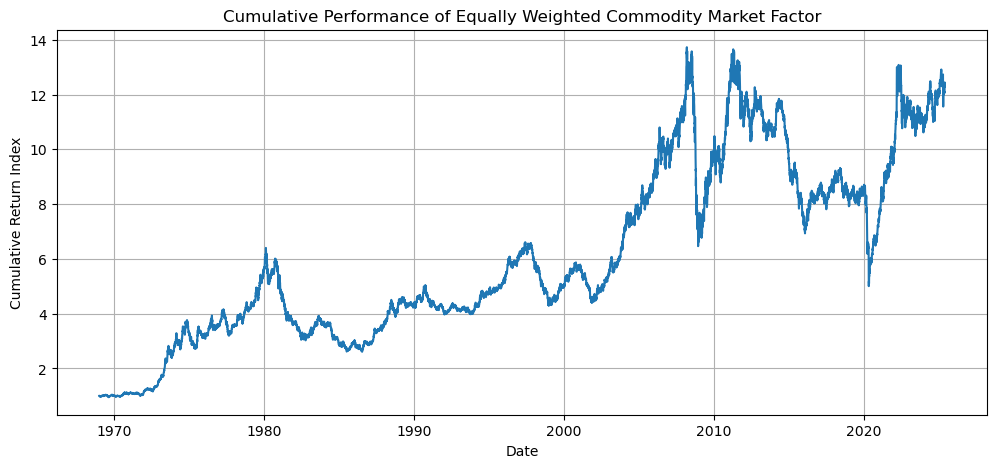

In [22]:
market_cum_return = (1 + commodity_market_factor.dropna()).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(market_cum_return)
plt.title("Cumulative Performance of Equally Weighted Commodity Market Factor")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.grid(True)
plt.show()

In [24]:
sector_map = assets.set_index("Commodity")["Sector"]

missing_sector = [col for col in commodity_returns.columns if col not in sector_map.index]
print("Assets missing sector mapping:", missing_sector)

Assets missing sector mapping: []


In [25]:
sector_returns = (
    commodity_returns
    .T
    .groupby(sector_map)
    .mean()
    .T
)

sector_returns.head()

Sector,Agri & livestock,Energy,Metals
Date,,,
1969-01-02,0.003568,NaN,NaN
1969-01-03,0.000689,NaN,NaN
1969-01-06,-0.004818,NaN,NaN
1969-01-07,-0.005740,NaN,NaN
1969-01-08,-0.003637,NaN,NaN


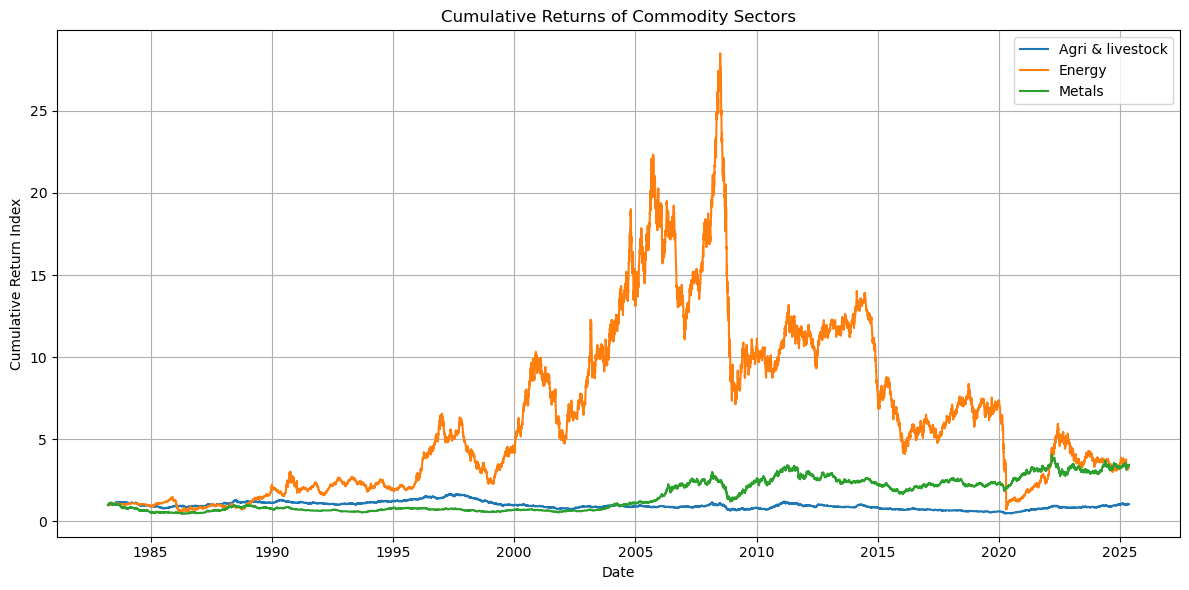

In [81]:
sector_returns_common = sector_returns.dropna(how="any")
sector_cum_returns_common = (1 + sector_returns_common).cumprod()

plt.figure(figsize=(12, 6))

for col in sector_cum_returns_common.columns:
    plt.plot(sector_cum_returns_common.index, sector_cum_returns_common[col], label=col)

plt.title("Cumulative Returns of Commodity Sectors")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Task 1

In [26]:
# -----------------------------
# Task 1: Strict Adaptive TSMOM parameters
# -----------------------------

LOOKBACK_CANDIDATES = [63, 126, 252]   # 3-month, 6-month, 12-month trend horizons
VOL_LOOKBACK_DAYS = 60                 # realised volatility for risk scaling
REBALANCE_FREQ = "M"                   # monthly rebalance
ANNUALISATION = 252

TRAIN_END = "2019-12-31"
TEST_START = "2020-01-01"

In [27]:
# set rebalance at the end of the month
def get_rebalance_mask(index, frequency="M"):

    if frequency.upper() == "D":
        return pd.Series(True, index=index)

    periods = pd.Series(index.to_period(frequency), index=index)
    rebalance_mask = periods.ne(periods.shift(-1))
    
    return rebalance_mask.fillna(True)

In [28]:
rebalance_mask = get_rebalance_mask(commodity_returns.index, REBALANCE_FREQ)

print("Number of rebalance dates:", rebalance_mask.sum())
print(commodity_returns.index[rebalance_mask][:10])

Number of rebalance dates: 677
DatetimeIndex(['1969-01-31', '1969-02-28', '1969-03-31', '1969-04-30', '1969-05-30', '1969-06-30', '1969-07-31', '1969-08-29', '1969-09-30', '1969-10-31'], dtype='datetime64[ns]', name='Date', freq=None)


In [29]:
def compute_past_cumulative_returns(returns, lookback_candidates):
    """
    Compute past cumulative returns for each candidate horizon.
    
    Output:
    dictionary:
        key = lookback horizon
        value = DataFrame of past cumulative returns
    """
    
    past_returns = {}
    
    for lb in lookback_candidates:
        past_cum_return = (
            (1 + returns)
            .rolling(window=lb, min_periods=lb)
            .apply(np.prod, raw=True)
            - 1
        )
        
        past_returns[lb] = past_cum_return
    
    return past_returns

In [30]:
# calculate the benchmark as the past cumulative return / realised volatility to select the best trend horizon
def compute_trend_scores(returns, lookback_candidates, annualisation=252):
    
    past_returns = compute_past_cumulative_returns(
        returns=returns,
        lookback_candidates=lookback_candidates
    )
    
    trend_scores = {}
    realised_vols_by_horizon = {}
    
    for lb in lookback_candidates:
        realised_vol = (
            returns
            .rolling(window=lb, min_periods=lb)
            .std()
            * np.sqrt(annualisation)
        )
        
        score = past_returns[lb] / realised_vol.replace(0, np.nan)
        
        trend_scores[lb] = score
        realised_vols_by_horizon[lb] = realised_vol
    
    return trend_scores, past_returns, realised_vols_by_horizon

In [ ]:
# select lookback horizon for each assets at each rebalance date
def generate_strict_adaptive_tsmom_signals(
    returns,
    lookback_candidates=[63, 126, 252],
    rebalance_freq="M",
    annualisation=252
):

    
    trend_scores, past_returns, realised_vols_by_horizon = compute_trend_scores(
        returns=returns,
        lookback_candidates=lookback_candidates,
        annualisation=annualisation
    )
    
    adaptive_signal = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)
    selected_lookback = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)
    selected_score = pd.DataFrame(index=returns.index, columns=returns.columns, dtype=float)
    
    for asset in returns.columns:
        asset_scores = pd.DataFrame({
            lb: trend_scores[lb][asset]
            for lb in lookback_candidates
        })
        
        asset_past_returns = pd.DataFrame({
            lb: past_returns[lb][asset]
            for lb in lookback_candidates
        })
        
        best_lb = asset_scores.abs().idxmax(axis=1)
        
        valid_rows = asset_scores.notna().any(axis=1)
        
        for date in returns.index[valid_rows]:
            lb = best_lb.loc[date]
            
            selected_lookback.loc[date, asset] = lb
            selected_score.loc[date, asset] = asset_scores.loc[date, lb]
            
            selected_return = asset_past_returns.loc[date, lb]
            
            if selected_return > 0:
                adaptive_signal.loc[date, asset] = 1.0
            elif selected_return < 0:
                adaptive_signal.loc[date, asset] = -1.0
            else:
                adaptive_signal.loc[date, asset] = 0.0
    
    if rebalance_freq.upper() != "D":
        rebalance_mask = get_rebalance_mask(returns.index, rebalance_freq)
        
        adaptive_signal.loc[~rebalance_mask, :] = np.nan
        selected_lookback.loc[~rebalance_mask, :] = np.nan
        selected_score.loc[~rebalance_mask, :] = np.nan
        
        adaptive_signal = adaptive_signal.ffill()
        selected_lookback = selected_lookback.ffill()
        selected_score = selected_score.ffill()
    
    return adaptive_signal, selected_lookback, selected_score, trend_scores, past_returns

In [33]:
adaptive_signals, selected_lookback, selected_score, adaptive_trend_scores, adaptive_past_returns = generate_strict_adaptive_tsmom_signals(
    returns=commodity_returns,
    lookback_candidates=LOOKBACK_CANDIDATES,
    rebalance_freq=REBALANCE_FREQ,
    annualisation=ANNUALISATION
)

C:\Users\26434\AppData\Local\Temp\ipykernel_14544\3601314629.py:34: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_lb = asset_scores.abs().idxmax(axis=1)
C:\Users\26434\AppData\Local\Temp\ipykernel_14544\3601314629.py:34: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_lb = asset_scores.abs().idxmax(axis=1)
C:\Users\26434\AppData\Local\Temp\ipykernel_14544\3601314629.py:34: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  best_lb = asset_scores.abs().idxmax(axis=1)
C:\Users\26434\AppData\Local\Temp\ipykernel_14544\3601314629.py:34: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a 

In [34]:
adaptive_signal_distribution = adaptive_signals.stack().value_counts(dropna=True).sort_index()
adaptive_signal_distribution

-1.0    130327
 0.0        21
 1.0    135605
Name: count, dtype: int64

In [ ]:
selected_lookback_distribution = selected_lookback.stack().value_counts(dropna=True).sort_index()
selected_lookback_distribution


63.0     0.152662
126.0    0.251311
252.0    0.596026
Name: proportion, dtype: float64

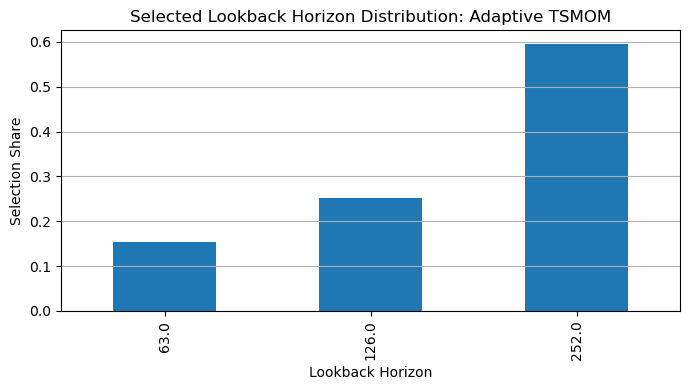

In [36]:
selected_lookback_share = selected_lookback.stack().value_counts(normalize=True, dropna=True).sort_index()
plt.figure(figsize=(7, 4))
selected_lookback_share.sort_index().plot(kind="bar")
plt.title("Selected Lookback Horizon Distribution: Adaptive TSMOM")
plt.xlabel("Lookback Horizon")
plt.ylabel("Selection Share")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Each lookback candidates has been selected which means the adaptive TSMOM strategy is effective

In [38]:
# alternative strategy: TSMOM signal based on fixed 12 months lookback 
def generate_tsmom_signals(returns, lookback=252, rebalance_freq="M"):

    
    past_cum_return = (
        (1 + returns)
        .rolling(window=lookback, min_periods=lookback)
        .apply(np.prod, raw=True)
        - 1
    )
    
    raw_signal = pd.DataFrame(
        np.where(past_cum_return > 0, 1,
                 np.where(past_cum_return < 0, -1, 0)),
        index=returns.index,
        columns=returns.columns
    )
    
    raw_signal = raw_signal.where(past_cum_return.notna())
    
    if rebalance_freq.upper() != "D":
        rebalance_mask = get_rebalance_mask(returns.index, rebalance_freq)
        signal = raw_signal.copy()
        signal.loc[~rebalance_mask, :] = np.nan
        signal = signal.ffill()
    else:
        signal = raw_signal.copy()
    
    return signal, past_cum_return

In [39]:
baseline_signals, baseline_past_returns = generate_tsmom_signals(
    returns=commodity_returns,
    rebalance_freq=REBALANCE_FREQ
)

baseline_signals.tail()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
2025-05-09,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0
2025-05-12,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0
2025-05-13,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0
2025-05-14,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0
2025-05-15,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0


In [40]:
signal_distribution = baseline_signals.stack().value_counts(dropna=True).sort_index()
signal_distribution

-1.0    134231
 1.0    127360
Name: count, dtype: int64

In [73]:
# construct inverse volatility weighted portfolio weights based on the input signals and the realised volatility estimate
def construct_inverse_vol_weights(
    returns,
    signals,
    vol_lookback=60,
    rebalance_freq="M",
    annualisation=252
):

    
    # realized volatility estimate
    realised_vol = (
        returns
        .rolling(window=vol_lookback, min_periods=vol_lookback)
        .std()
        * np.sqrt(annualisation)
    )
    
    # inverse volatility
    inv_vol = 1 / realised_vol.replace(0, np.nan)
    
    # raw weights
    raw_weights_daily = signals * inv_vol
    

    if rebalance_freq.upper() != "D":
        rebalance_mask = get_rebalance_mask(returns.index, rebalance_freq)
        raw_weights = raw_weights_daily.copy()
        raw_weights.loc[~rebalance_mask, :] = np.nan
        raw_weights = raw_weights.ffill()
    else:
        raw_weights = raw_weights_daily.copy()
    
    # gross exposure normalisation
    raw_weights = raw_weights.replace([np.inf, -np.inf], np.nan)
    raw_weights = raw_weights.where(returns.notna(), np.nan)

    gross_exposure = raw_weights.abs().sum(axis=1).replace(0, np.nan)
    weights = raw_weights.div(gross_exposure, axis=0).fillna(0.0)
    
    return weights, realised_vol

In [74]:
baseline_weights, baseline_realised_vol = construct_inverse_vol_weights(
    returns=commodity_returns,
    signals=baseline_signals,
    vol_lookback=VOL_LOOKBACK_DAYS,
    rebalance_freq=REBALANCE_FREQ,
    annualisation=ANNUALISATION
)

baseline_weights.tail()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
2025-05-09,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,-0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-12,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,-0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-13,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,-0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-14,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,-0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-15,0.069836,0.045952,0.031084,-0.057554,-0.045894,-0.065558,0.042495,-0.053297,-0.032921,-0.030854,-0.036719,0.043671,-0.017110,-0.032718,-0.043026,-0.029803,-0.043256,-0.046502,-0.062644,-0.062956,-0.053109,0.016622,-0.036418


In [75]:
gross_exposure = baseline_weights.abs().sum(axis=1)
net_exposure = baseline_weights.sum(axis=1)

print(gross_exposure.describe())
print(net_exposure.describe())

count    14706.000000
mean         0.982388
std          0.131540
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
dtype: float64
count    14706.000000
mean        -0.024527
std          0.462655
min         -1.000000
25%         -0.350376
50%         -0.005084
75%          0.307159
max          1.000000
dtype: float64


In [76]:
adaptive_weights, adaptive_realised_vol = construct_inverse_vol_weights(
    returns=commodity_returns,
    signals=adaptive_signals,
    vol_lookback=VOL_LOOKBACK_DAYS,
    rebalance_freq=REBALANCE_FREQ,
    annualisation=ANNUALISATION
)

adaptive_weights.tail()

,LIVE CATTLE,LEAN HOGS,COFFEE 'C',CORN,COTTON NO.2,SOYBEAN,SUGAR #11,WHEAT FUTURE,BRENT CRUDE,COPPER FUTURE,GASOLINE RBOB,GOLD 100 OZ,NATURAL GAS,SILVER,PLATINUM,WTI CRUDE,LME NICKEL,LME COPPER,LME ALUMINIUM,LME LEAD,LME ZINC,COCOA,HEATING OIL
Date,,,,,,,,,,,,,,,,,,,,,,,
2025-05-09,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,-0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-12,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,-0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-13,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,-0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-14,0.065939,0.042711,0.027169,-0.057394,-0.047317,-0.068837,-0.042258,-0.049300,-0.034596,-0.029324,-0.036946,0.050356,0.016482,0.032658,-0.044157,-0.031068,-0.042345,-0.045921,-0.064375,-0.064367,-0.052431,0.017078,-0.036971
2025-05-15,0.069836,0.045952,0.031084,-0.057554,-0.045894,-0.065558,-0.042495,-0.053297,-0.032921,0.030854,-0.036719,0.043671,0.017110,-0.032718,-0.043026,-0.029803,-0.043256,-0.046502,-0.062644,-0.062956,-0.053109,0.016622,-0.036418


In [77]:
adaptive_gross_exposure = adaptive_weights.abs().sum(axis=1)
adaptive_net_exposure = adaptive_weights.sum(axis=1)

print(adaptive_gross_exposure.describe())
print(adaptive_net_exposure.describe())

count    14706.000000
mean         0.995784
std          0.064796
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
dtype: float64
count    14706.000000
mean         0.011943
std          0.465773
min         -1.000000
25%         -0.320428
50%          0.021500
75%          0.390164
max          1.000000
dtype: float64


In [78]:
# to avoid look-ahead bias, we shift the weights by 1 day
def backtest_from_weights(returns, weights, strategy_name="Strategy"):
    
    shifted_weights = weights.shift(1)
    
    asset_contributions = shifted_weights * returns
    
    strategy_returns = asset_contributions.sum(axis=1, min_count=1)
    
    active_mask = shifted_weights.abs().sum(axis=1) > 0
    strategy_returns = strategy_returns.loc[active_mask].fillna(0.0)
    asset_contributions = asset_contributions.loc[strategy_returns.index].fillna(0.0)
    
    strategy_returns.name = strategy_name
    
    return strategy_returns, asset_contributions

In [47]:
baseline_strategy_returns, baseline_asset_contributions = backtest_from_weights(
    returns=commodity_returns,
    weights=baseline_weights,
    strategy_name="Baseline_TSMOM"
)

baseline_strategy_returns.head()

Date
1970-01-01    0.000000
1970-01-02    0.000000
1970-01-05   -0.004691
1970-01-06    0.004881
1970-01-07    0.004009
Name: Baseline_TSMOM, dtype: float64

In [48]:
print("Strategy start date:", baseline_strategy_returns.index.min())
print("Strategy end date:", baseline_strategy_returns.index.max())
print("Number of observations:", baseline_strategy_returns.shape[0])

Strategy start date: 1970-01-01 00:00:00
Strategy end date: 2025-05-15 00:00:00
Number of observations: 14446


In [49]:
adaptive_strategy_returns, adaptive_asset_contributions = backtest_from_weights(
    returns=commodity_returns,
    weights=adaptive_weights,
    strategy_name="Adaptive_TSMOM"
)

adaptive_strategy_returns.head()

Date
1969-04-01   -0.000383
1969-04-02    0.001361
1969-04-03   -0.001822
1969-04-04    0.000000
1969-04-07    0.000048
Name: Adaptive_TSMOM, dtype: float64

In [50]:
print("Adaptive TSMOM start date:", adaptive_strategy_returns.index.min())
print("Adaptive TSMOM end date:", adaptive_strategy_returns.index.max())
print("Number of observations:", adaptive_strategy_returns.shape[0])

Adaptive TSMOM start date: 1969-04-01 00:00:00
Adaptive TSMOM end date: 2025-05-15 00:00:00
Number of observations: 14643


In [51]:
def calculate_max_drawdown(return_series):

    return_series = return_series.dropna()
    cumulative = (1 + return_series).cumprod()
    running_max = cumulative.cummax()
    drawdown = cumulative / running_max - 1
    return drawdown.min()


def performance_summary(returns, annualisation=252):
    
    if isinstance(returns, pd.Series):
        returns = returns.to_frame()
    
    summary = pd.DataFrame(index=returns.columns)
    
    n_obs = returns.count()
    total_return = (1 + returns).prod() - 1
    years = n_obs / annualisation
    
    cagr = (1 + total_return) ** (1 / years) - 1
    
    ann_mean = returns.mean() * annualisation
    ann_vol = returns.std() * np.sqrt(annualisation)
    sharpe = ann_mean / ann_vol
    
    downside_vol = returns.where(returns < 0).std() * np.sqrt(annualisation)
    sortino = ann_mean / downside_vol
    
    max_dd = returns.apply(calculate_max_drawdown)
    calmar = cagr / max_dd.abs()
    
    hit_rate = (returns > 0).sum() / n_obs
    
    summary["Observations"] = n_obs
    summary["Total Return"] = total_return
    summary["CAGR"] = cagr
    summary["Annualised Mean Return"] = ann_mean
    summary["Annualised Volatility"] = ann_vol
    summary["Sharpe Ratio"] = sharpe
    summary["Sortino Ratio"] = sortino
    summary["Max Drawdown"] = max_dd
    summary["Calmar Ratio"] = calmar
    summary["Skewness"] = returns.skew()
    summary["Kurtosis"] = returns.kurtosis()
    summary["Hit Rate"] = hit_rate
    
    return summary

In [52]:
comparison_returns = pd.concat(
    [
        baseline_strategy_returns,
        commodity_market_factor.rename("Commodity_Market_Factor")
    ],
    axis=1
).dropna()

comparison_returns.head()

,Baseline_TSMOM,Commodity_Market_Factor
Date,,
1970-01-01,0.000000,0.000000
1970-01-02,0.000000,0.000000
1970-01-05,-0.004691,0.003388
1970-01-06,0.004881,0.000453
1970-01-07,0.004009,0.002583


In [53]:
summary_full = performance_summary(comparison_returns, annualisation=ANNUALISATION)
summary_train = performance_summary(comparison_returns.loc[:TRAIN_END], annualisation=ANNUALISATION)
summary_test = performance_summary(comparison_returns.loc[TEST_START:], annualisation=ANNUALISATION)

print("Full sample performance:")
display(summary_full.round(4))

print("Training sample performance:")
display(summary_train.round(4))

print("Test sample performance:")
display(summary_test.round(4))

Full sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Baseline_TSMOM,14446,46.7893,0.0698,0.0716,0.0907,0.7894,1.0749,-0.3736,0.1868,-0.2411,5.4409,0.5209
Commodity_Market_Factor,14446,11.4774,0.0450,0.0531,0.1342,0.3954,0.5297,-0.6354,0.0708,-0.5904,9.2871,0.5130


Training sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Baseline_TSMOM,13044,36.6852,0.0726,0.0742,0.0902,0.8226,1.1130,-0.3736,0.1944,-0.2983,5.2353,0.5222
Commodity_Market_Factor,13044,7.7450,0.0428,0.0504,0.1302,0.3869,0.5431,-0.5924,0.0722,-0.1468,3.7970,0.5083


Test sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Baseline_TSMOM,1402,0.2681,0.0436,0.0472,0.0949,0.4972,0.7156,-0.1570,0.2779,0.2218,6.9933,0.5093
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


In [54]:
comparison_returns = pd.concat(
    [
        adaptive_strategy_returns,
        commodity_market_factor.rename("Commodity_Market_Factor")
    ],
    axis=1
).dropna()

comparison_returns.head()

,Adaptive_TSMOM,Commodity_Market_Factor
Date,,
1969-04-01,-0.000383,0.009329
1969-04-02,0.001361,0.000504
1969-04-03,-0.001822,-0.001189
1969-04-04,0.000000,0.000000
1969-04-07,0.000048,0.003684


In [55]:
summary_full = performance_summary(comparison_returns, annualisation=ANNUALISATION)
summary_train = performance_summary(comparison_returns.loc[:TRAIN_END], annualisation=ANNUALISATION)
summary_test = performance_summary(comparison_returns.loc[TEST_START:], annualisation=ANNUALISATION)

print("Full sample performance:")
display(summary_full.round(4))

print("Training sample performance:")
display(summary_train.round(4))

print("Test sample performance:")
display(summary_test.round(4))

Full sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM,14643,76.8705,0.0778,0.0790,0.0895,0.8825,1.2185,-0.3173,0.2453,-0.0991,5.7391,0.5197
Commodity_Market_Factor,14643,11.5249,0.0445,0.0525,0.1336,0.3927,0.5256,-0.6354,0.0700,-0.5910,9.3540,0.5127


Training sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM,13241,53.1796,0.0789,0.0799,0.0884,0.9036,1.2431,-0.3036,0.2600,-0.1674,5.4329,0.5205
Commodity_Market_Factor,13241,7.7783,0.0422,0.0497,0.1296,0.3839,0.5384,-0.5924,0.0713,-0.1473,3.8375,0.5080


Test sample performance:


,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM,1402,0.4373,0.0674,0.0701,0.0989,0.7086,1.0103,-0.1871,0.3601,0.3673,7.3106,0.5121
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


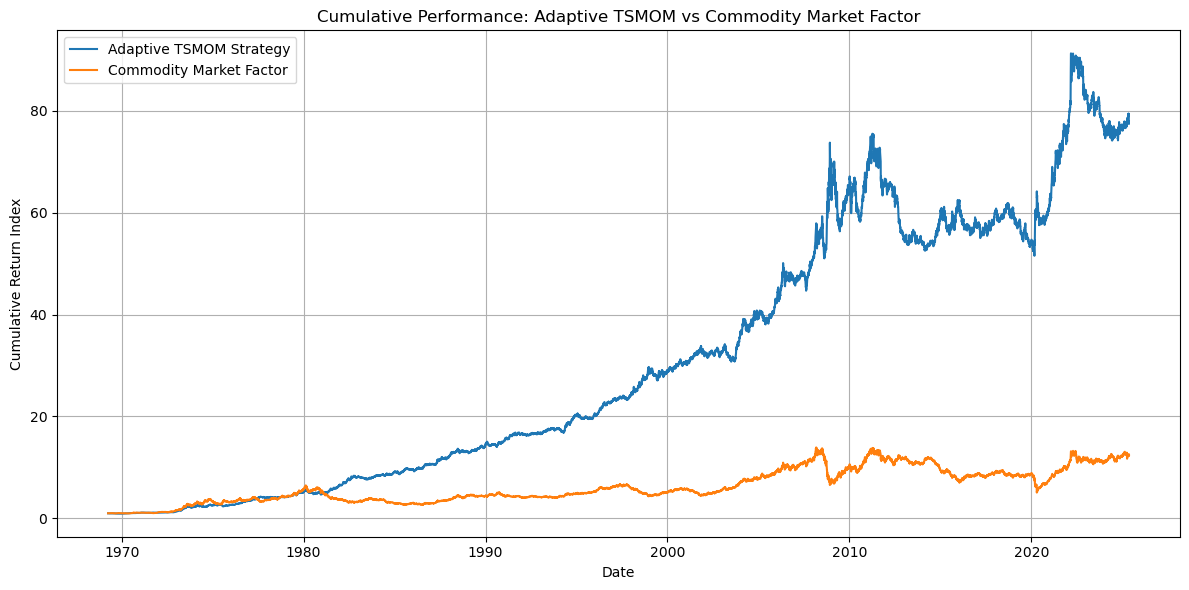

In [56]:
cumulative_comparison = (1 + comparison_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_comparison["Adaptive_TSMOM"], label="Adaptive TSMOM Strategy")
plt.plot(cumulative_comparison["Commodity_Market_Factor"], label="Commodity Market Factor")
plt.title("Cumulative Performance: Adaptive TSMOM vs Commodity Market Factor")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

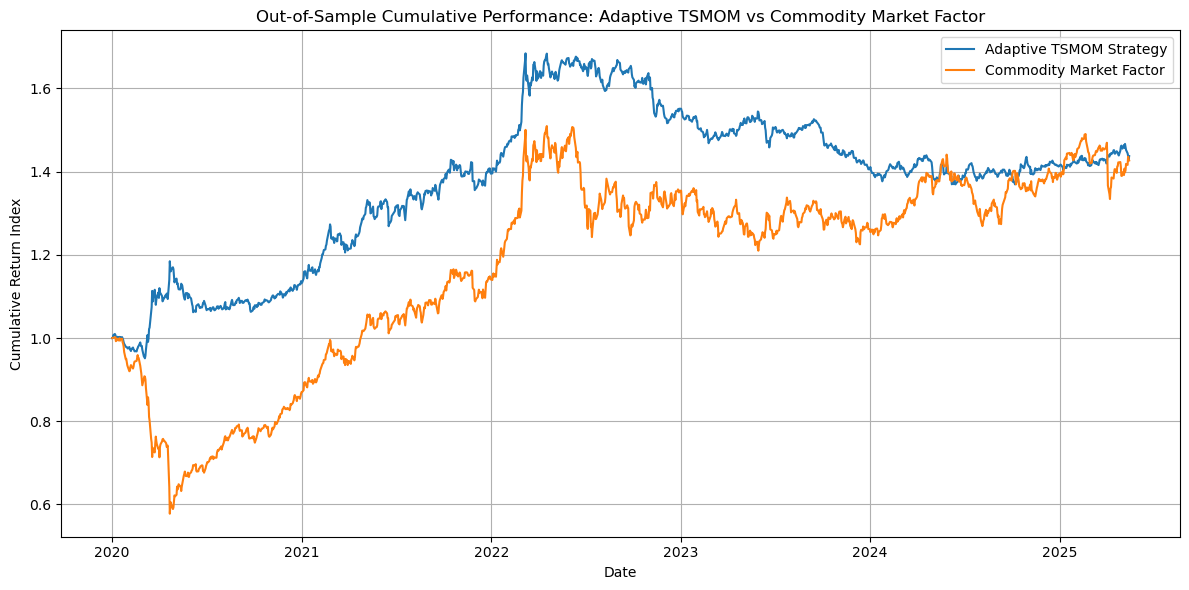

In [57]:
comparison_returns_test = comparison_returns.loc[TEST_START:]
cumulative_comparison_test = (1 + comparison_returns_test).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cumulative_comparison_test["Adaptive_TSMOM"], label="Adaptive TSMOM Strategy")
plt.plot(cumulative_comparison_test["Commodity_Market_Factor"], label="Commodity Market Factor")
plt.title("Out-of-Sample Cumulative Performance: Adaptive TSMOM vs Commodity Market Factor")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [58]:
strategy_comparison = pd.concat(
    [
        adaptive_strategy_returns.rename("Adaptive_TSMOM"),
        baseline_strategy_returns.rename("Fixed_12M_TSMOM"),
        commodity_market_factor.rename("Commodity_Market_Factor")
    ],
    axis=1
).dropna()

strategy_comparison_summary_test = performance_summary(
    strategy_comparison.loc[TEST_START:], 
    annualisation=ANNUALISATION
)

strategy_comparison_summary_test.round(4)

,Observations,Total Return,CAGR,Annualised Mean Return,Annualised Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Calmar Ratio,Skewness,Kurtosis,Hit Rate
Adaptive_TSMOM,1402,0.4373,0.0674,0.0701,0.0989,0.7086,1.0103,-0.1871,0.3601,0.3673,7.3106,0.5121
Fixed_12M_TSMOM,1402,0.2681,0.0436,0.0472,0.0949,0.4972,0.7156,-0.1570,0.2779,0.2218,6.9933,0.5093
Commodity_Market_Factor,1402,0.4268,0.0660,0.0780,0.1667,0.4682,0.5045,-0.4236,0.1558,-2.5387,26.8413,0.5571


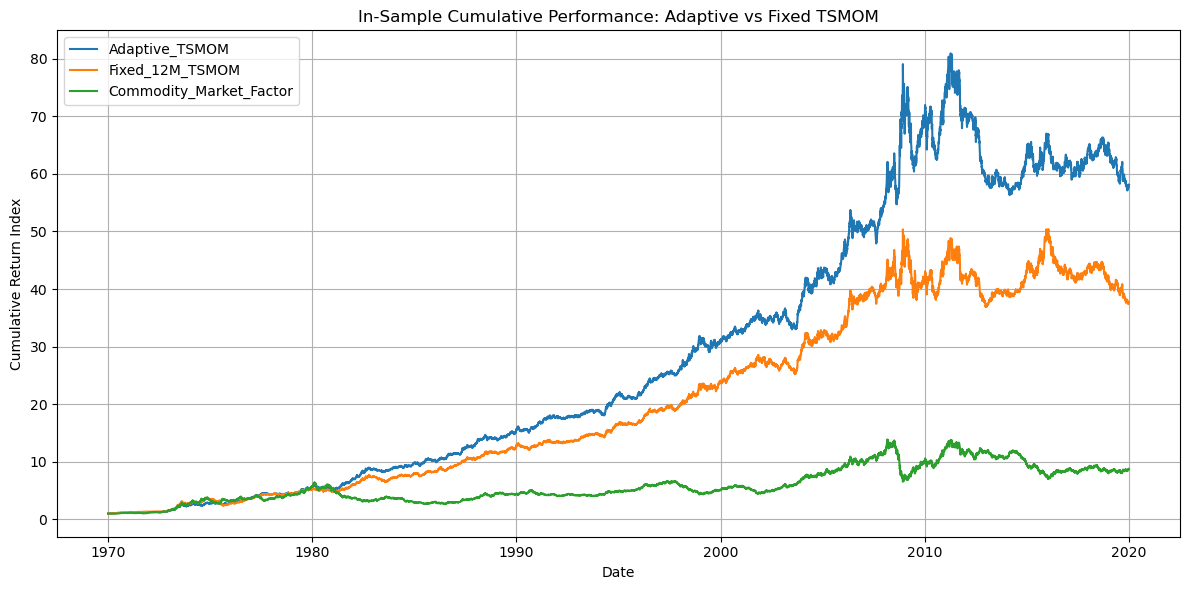

In [80]:
strategy_comparison_train_cum = (1 + strategy_comparison.loc[:TEST_START]).cumprod()

plt.figure(figsize=(12, 6))
for col in strategy_comparison_train_cum.columns:
    plt.plot(strategy_comparison_train_cum[col], label=col)

plt.title("In-Sample Cumulative Performance: Adaptive vs Fixed TSMOM")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

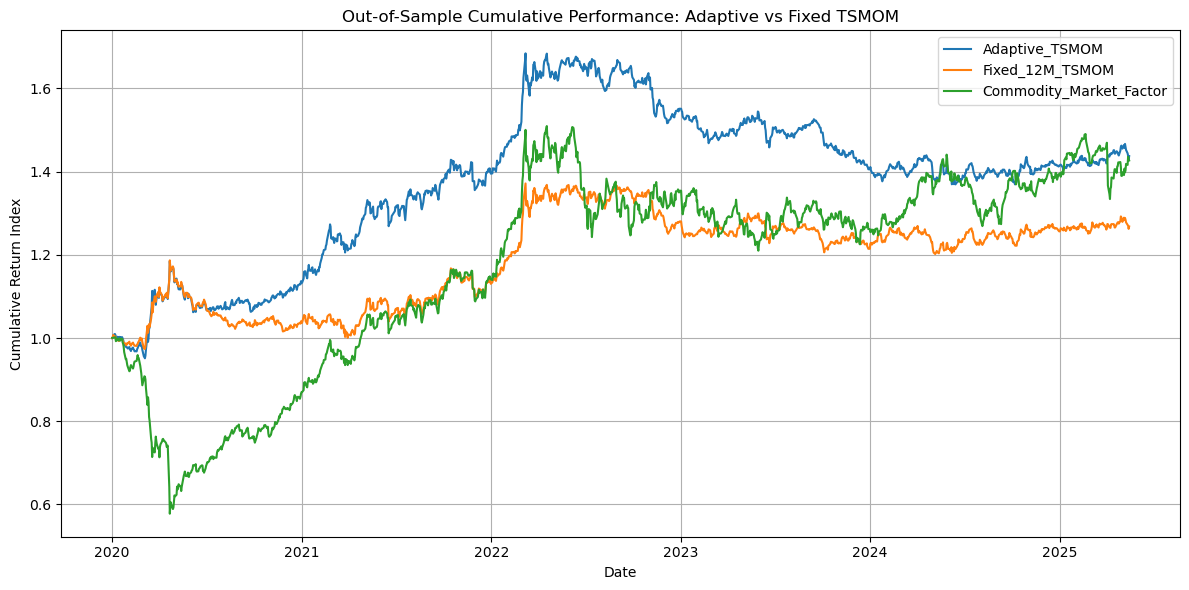

In [59]:
strategy_comparison_test_cum = (1 + strategy_comparison.loc[TEST_START:]).cumprod()

plt.figure(figsize=(12, 6))
for col in strategy_comparison_test_cum.columns:
    plt.plot(strategy_comparison_test_cum[col], label=col)

plt.title("Out-of-Sample Cumulative Performance: Adaptive vs Fixed TSMOM")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
# run regression of strategy returns on the commodity market factor
def run_market_beta_regression(strategy_returns, market_factor, hac_lags=5):
    """
    Regress strategy returns on the commodity market factor.

    Model:
        strategy return = alpha + beta * commodity market factor + error

    HAC standard errors are used to account for heteroskedasticity 
    and mild autocorrelation.
    """

    reg_data = pd.concat(
        [
            strategy_returns.rename("Strategy_Return"),
            market_factor.rename("Commodity_Market_Factor")
        ],
        axis=1
    ).dropna()

    y = reg_data["Strategy_Return"]
    X = sm.add_constant(reg_data["Commodity_Market_Factor"])

    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": hac_lags}
    )

    return model, reg_data

In [62]:
adaptive_market_beta_model_full, adaptive_reg_data_full = run_market_beta_regression(
    strategy_returns=adaptive_strategy_returns,
    market_factor=commodity_market_factor,
    hac_lags=5
)

print(adaptive_market_beta_model_full.summary())

                            OLS Regression Results                            
Dep. Variable:        Strategy_Return   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.934
Date:                Wed, 20 May 2026   Prob (F-statistic):             0.0868
Time:                        15:08:56   Log-Likelihood:                 55078.
No. Observations:               14643   AIC:                        -1.102e+05
Df Residuals:                   14641   BIC:                        -1.101e+05
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [63]:
adaptive_market_beta_model_test, adaptive_reg_data_test = run_market_beta_regression(
    strategy_returns=adaptive_strategy_returns.loc[TEST_START:],
    market_factor=commodity_market_factor.loc[TEST_START:],
    hac_lags=5
)

print(adaptive_market_beta_model_test.summary())

                            OLS Regression Results                            
Dep. Variable:        Strategy_Return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                   0.07766
Date:                Wed, 20 May 2026   Prob (F-statistic):              0.781
Time:                        15:08:58   Log-Likelihood:                 5131.9
No. Observations:                1402   AIC:                        -1.026e+04
Df Residuals:                    1400   BIC:                        -1.025e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

The R-squared is only 0.2%, indicating that the strategy is not primarily driven by passive exposure to the commodity market. There is no statistically significant evidence that the strategy is driven by commodity market beta in the test period. The estimated alpha is positive but not statistically significant in the test sample.

In [66]:
def compute_sector_contributions(asset_contributions, assets):

    sector_map = assets.set_index("Commodity")["Sector"]

    common_assets = [
        col for col in asset_contributions.columns
        if col in sector_map.index
    ]

    asset_contributions = asset_contributions[common_assets]

    sector_contributions = (
        asset_contributions
        .T
        .groupby(sector_map.loc[common_assets])
        .sum()
        .T
    )

    return sector_contributions

In [67]:
adaptive_sector_contributions = compute_sector_contributions(
    asset_contributions=adaptive_asset_contributions,
    assets=assets
)

adaptive_sector_contributions.head()

Sector,Agri & livestock,Energy,Metals
Date,,,
1969-04-01,-0.000383,0.0,0.0
1969-04-02,0.001361,0.0,0.0
1969-04-03,-0.001822,0.0,0.0
1969-04-04,0.000000,0.0,0.0
1969-04-07,0.000048,0.0,0.0


In [68]:
adaptive_sector_total_contribution = adaptive_sector_contributions.sum()
adaptive_total_strategy_arithmetic_return = adaptive_strategy_returns.sum()

adaptive_sector_contribution_table = pd.DataFrame({
    "Total Arithmetic Contribution": adaptive_sector_total_contribution,
    "Share of Total Arithmetic Return": adaptive_sector_total_contribution / adaptive_total_strategy_arithmetic_return,
    "Absolute Contribution Share": adaptive_sector_total_contribution.abs() / adaptive_sector_total_contribution.abs().sum()
})

adaptive_sector_contribution_table.round(4)

,Total Arithmetic Contribution,Share of Total Arithmetic Return,Absolute Contribution Share
Sector,,,
Agri & livestock,2.5473,0.5552,0.5552
Energy,0.9360,0.2040,0.2040
Metals,1.1050,0.2408,0.2408


In [69]:
adaptive_sector_contribution_train = adaptive_sector_contributions.loc[:TRAIN_END].sum()
adaptive_sector_contribution_test = adaptive_sector_contributions.loc[TEST_START:].sum()

adaptive_sector_contribution_train_test = pd.DataFrame({
    "Train Contribution": adaptive_sector_contribution_train,
    "Test Contribution": adaptive_sector_contribution_test
})

adaptive_sector_contribution_train_test["Train Share"] = (
    adaptive_sector_contribution_train_test["Train Contribution"]
    / adaptive_sector_contribution_train_test["Train Contribution"].sum()
)

adaptive_sector_contribution_train_test["Test Share"] = (
    adaptive_sector_contribution_train_test["Test Contribution"]
    / adaptive_sector_contribution_train_test["Test Contribution"].sum()
)

adaptive_sector_contribution_train_test.round(4)

,Train Contribution,Test Contribution,Train Share,Test Share
Sector,,,,
Agri & livestock,2.4074,0.1399,0.5734,0.3589
Energy,0.6884,0.2476,0.1640,0.6350
Metals,1.1026,0.0024,0.2626,0.0061


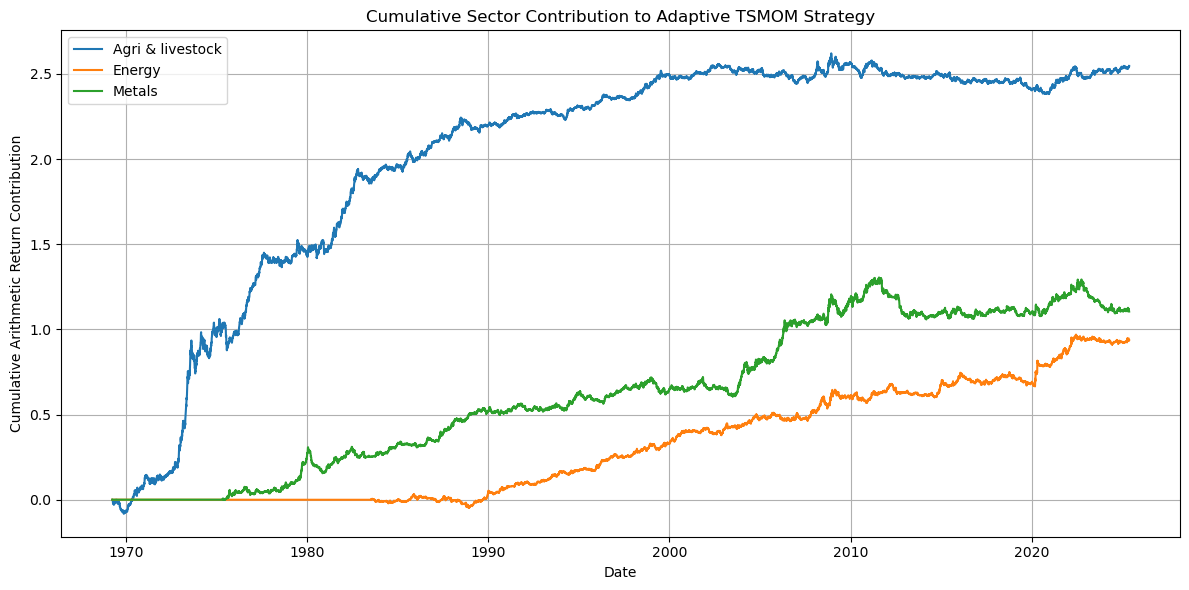

In [70]:
adaptive_sector_cumulative_contribution = adaptive_sector_contributions.cumsum()

plt.figure(figsize=(12, 6))

for sector in adaptive_sector_cumulative_contribution.columns:
    plt.plot(adaptive_sector_cumulative_contribution[sector], label=sector)

plt.title("Cumulative Sector Contribution to Adaptive TSMOM Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Arithmetic Return Contribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

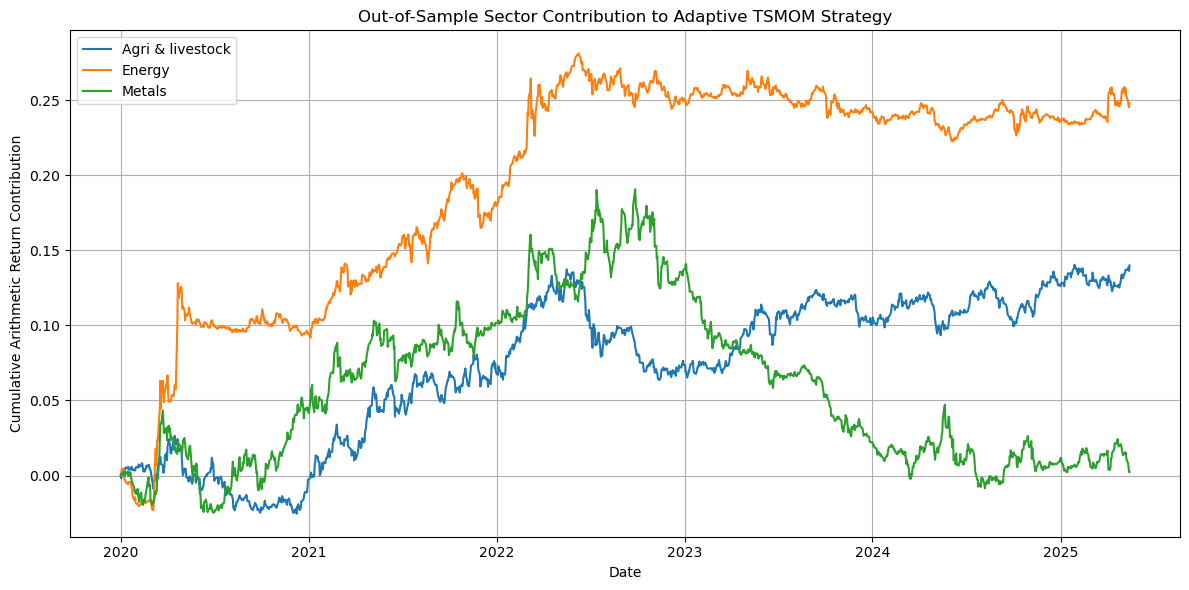

In [71]:
adaptive_sector_cumulative_contribution_test = adaptive_sector_contributions.loc[TEST_START:].cumsum()

plt.figure(figsize=(12, 6))

for sector in adaptive_sector_cumulative_contribution_test.columns:
    plt.plot(adaptive_sector_cumulative_contribution_test[sector], label=sector)

plt.title("Out-of-Sample Sector Contribution to Adaptive TSMOM Strategy")
plt.xlabel("Date")
plt.ylabel("Cumulative Arithmetic Return Contribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

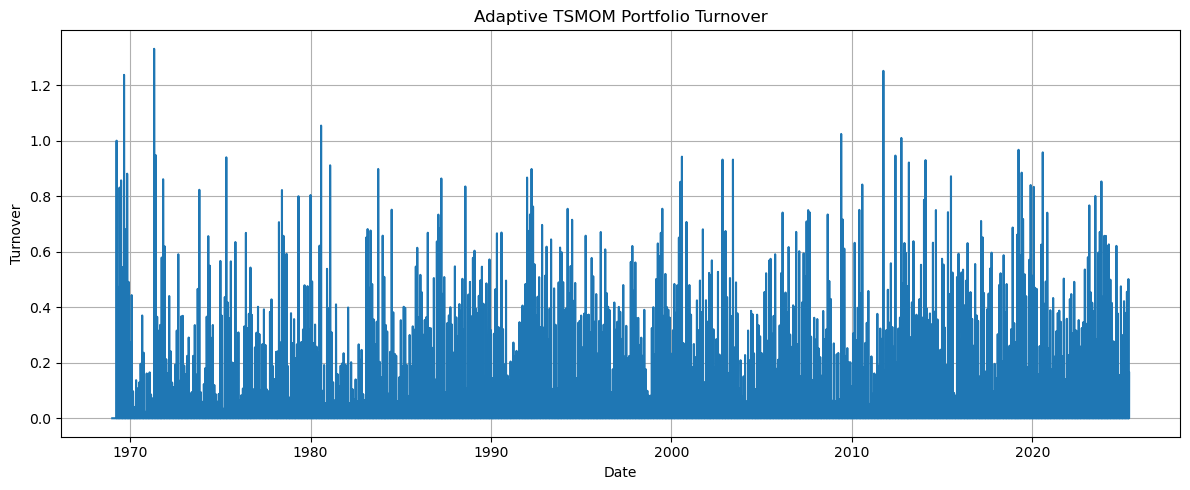

In [72]:
adaptive_turnover = adaptive_weights.diff().abs().sum(axis=1)
adaptive_turnover.name = "Adaptive_TSMOM_Turnover"
plt.figure(figsize=(12, 5))
plt.plot(adaptive_turnover)
plt.title("Adaptive TSMOM Portfolio Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover")
plt.grid(True)
plt.tight_layout()
plt.show()

In [87]:
adaptive_gross_exposure = adaptive_weights.abs().sum(axis=1)
adaptive_net_exposure = adaptive_weights.sum(axis=1)

adaptive_exposure_summary = pd.DataFrame({
    "Gross Exposure": adaptive_gross_exposure,
    "Net Exposure": adaptive_net_exposure
})

adaptive_exposure_summary.describe().round(4)

,Gross Exposure,Net Exposure
count,14706.0000,14706.0000
mean,0.9958,0.0119
std,0.0648,0.4658
min,0.0000,-1.0000
25%,1.0000,-0.3204
50%,1.0000,0.0215
75%,1.0000,0.3902
max,1.0000,1.0000


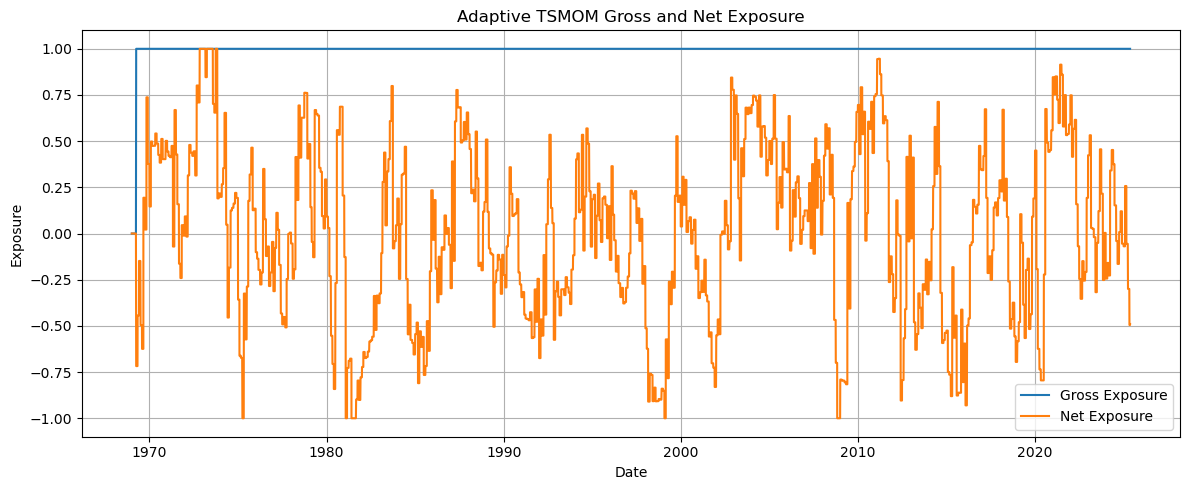

In [89]:
plt.figure(figsize=(12, 5))
plt.plot(adaptive_gross_exposure, label="Gross Exposure")
plt.plot(adaptive_net_exposure, label="Net Exposure")
plt.title("Adaptive TSMOM Gross and Net Exposure")
plt.xlabel("Date")
plt.ylabel("Exposure")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We control the gross exposure to 1 as we normalise the weights